In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [107]:
data = pd.read_csv('hotel_bookings.csv')
df =data.copy()

In [108]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [109]:
df.shape

(119390, 32)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

#     1- EDA

In [111]:
df.isna().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [112]:
df.duplicated().sum()

np.int64(31994)

In [113]:
cat_col = df.select_dtypes(exclude='number').columns

In [114]:
cat_col

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

In [115]:
numeric_col = df.select_dtypes(include='number').columns

In [116]:
numeric_col

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

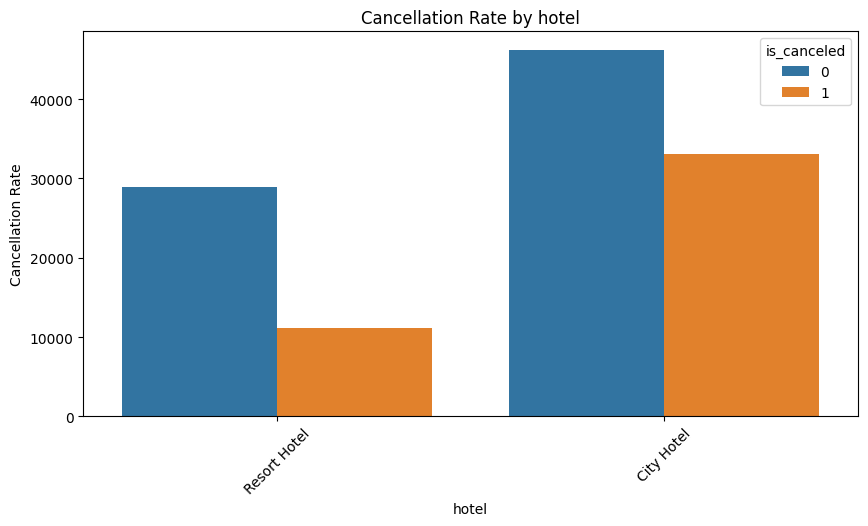

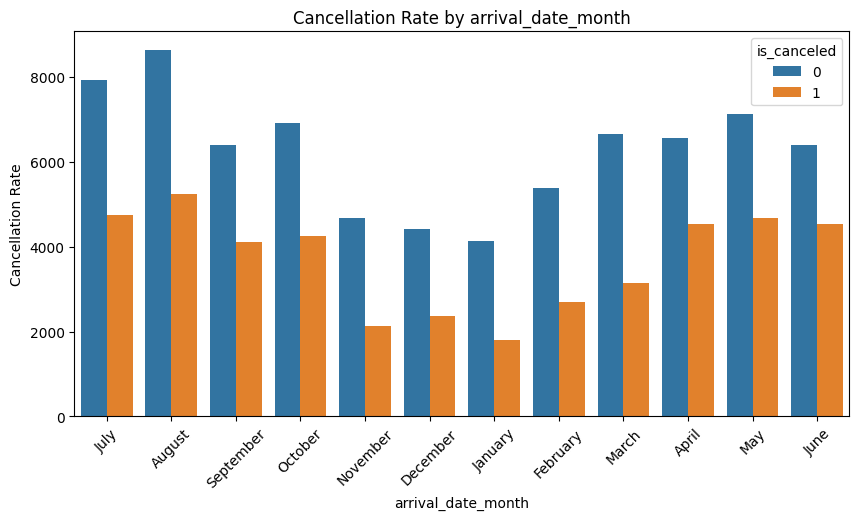

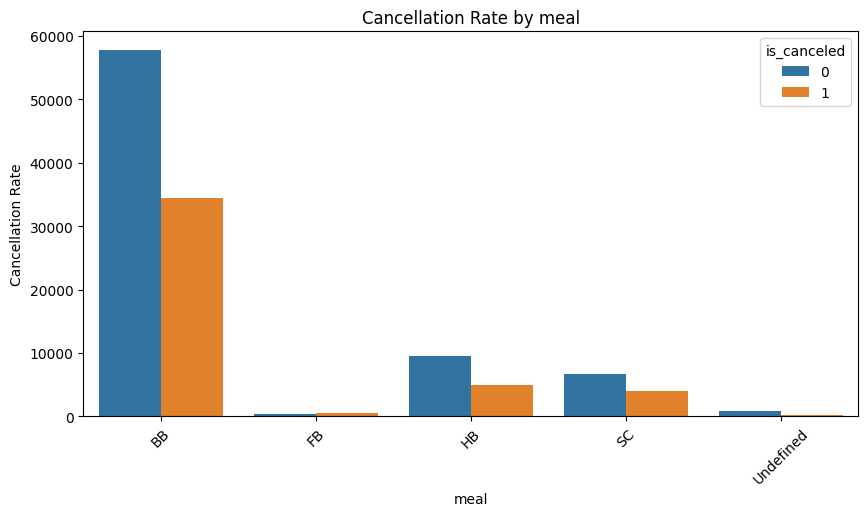

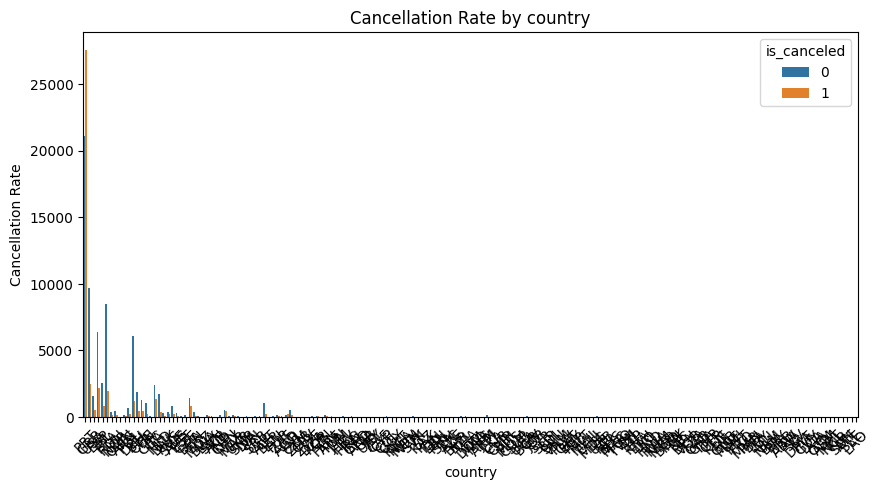

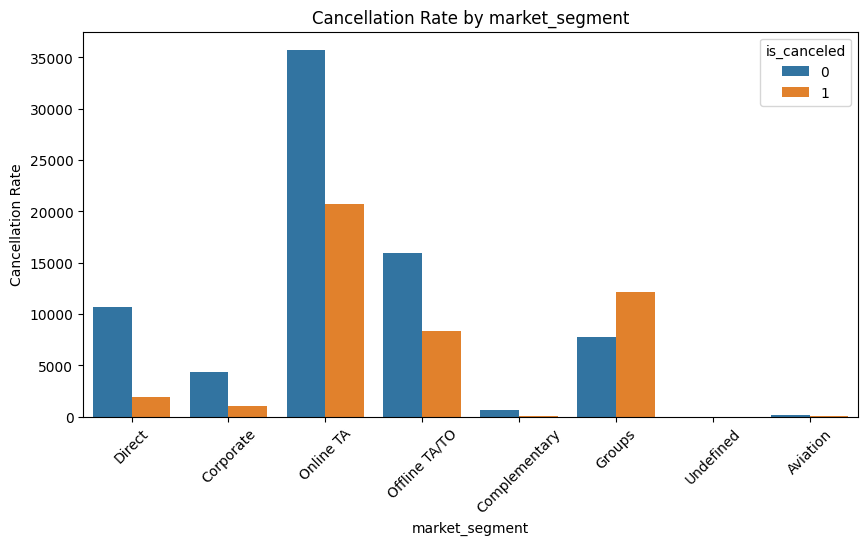

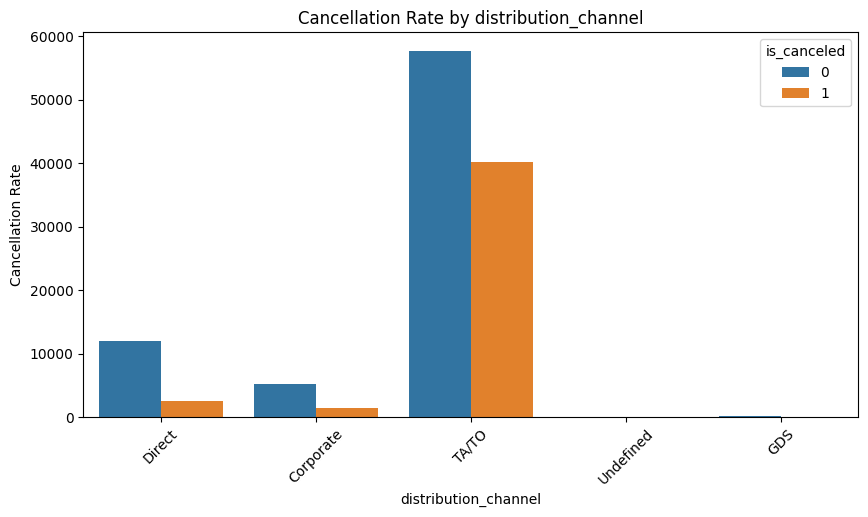

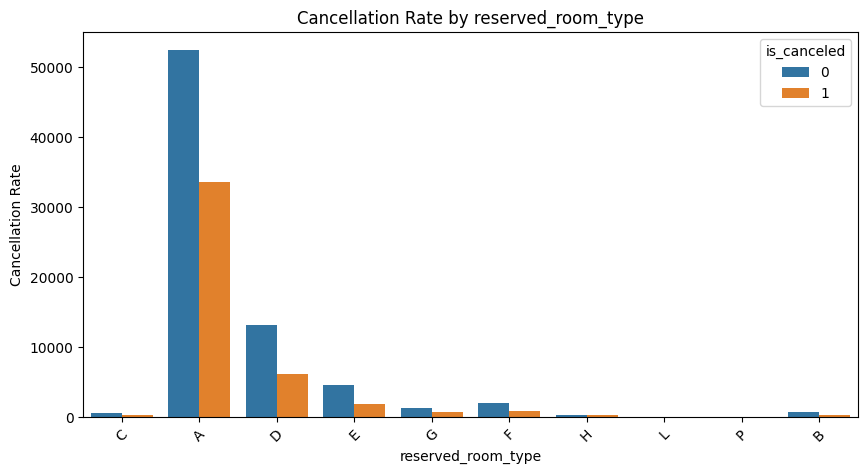

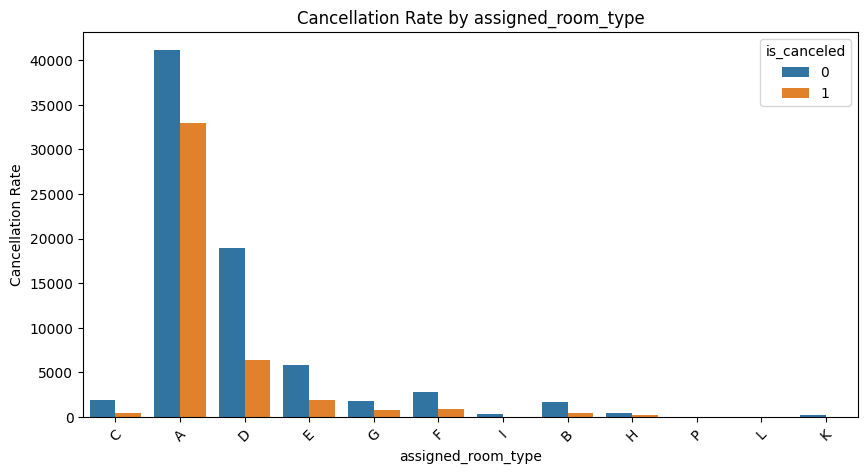

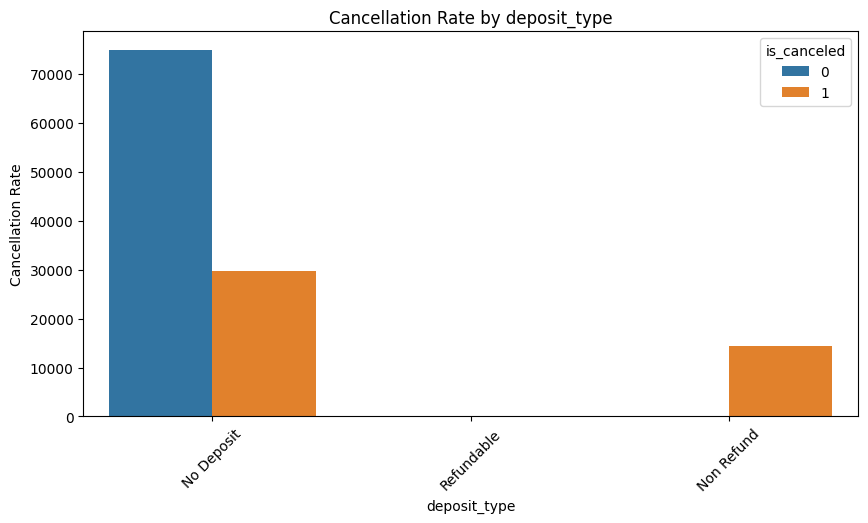

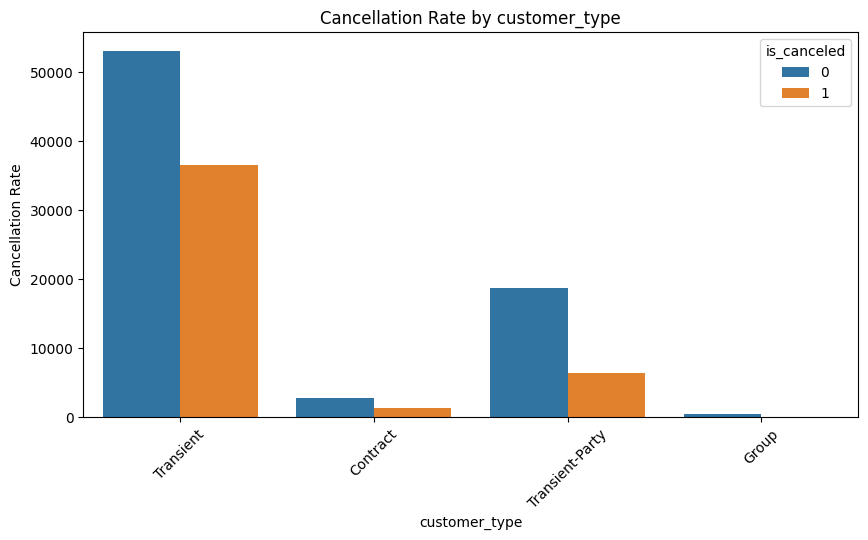

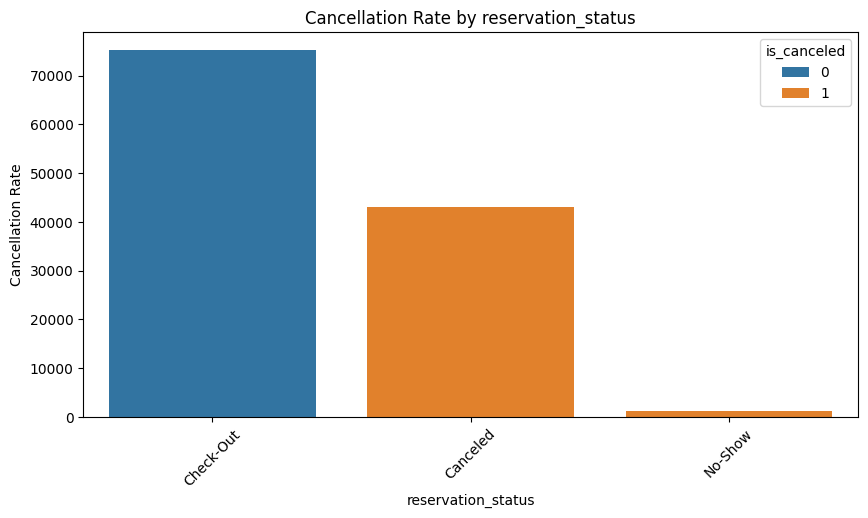

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
    'distribution_channel', 'reserved_room_type', 'assigned_room_type',
    'deposit_type', 'customer_type', 'reservation_status'
]

for col in features:
    plt.figure(figsize=(10,5))
    
    sns.countplot(data=df, x=col, hue='is_canceled')
    plt.xticks(rotation=45)

    plt.title(f'Cancellation Rate by {col}')
    plt.ylabel('Cancellation Rate')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()

In [118]:
#check values for each category col
for col in cat_col:
    print(df[col].value_counts())
    print('-'*100)




hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 177, dtype: int64
--------------------------------

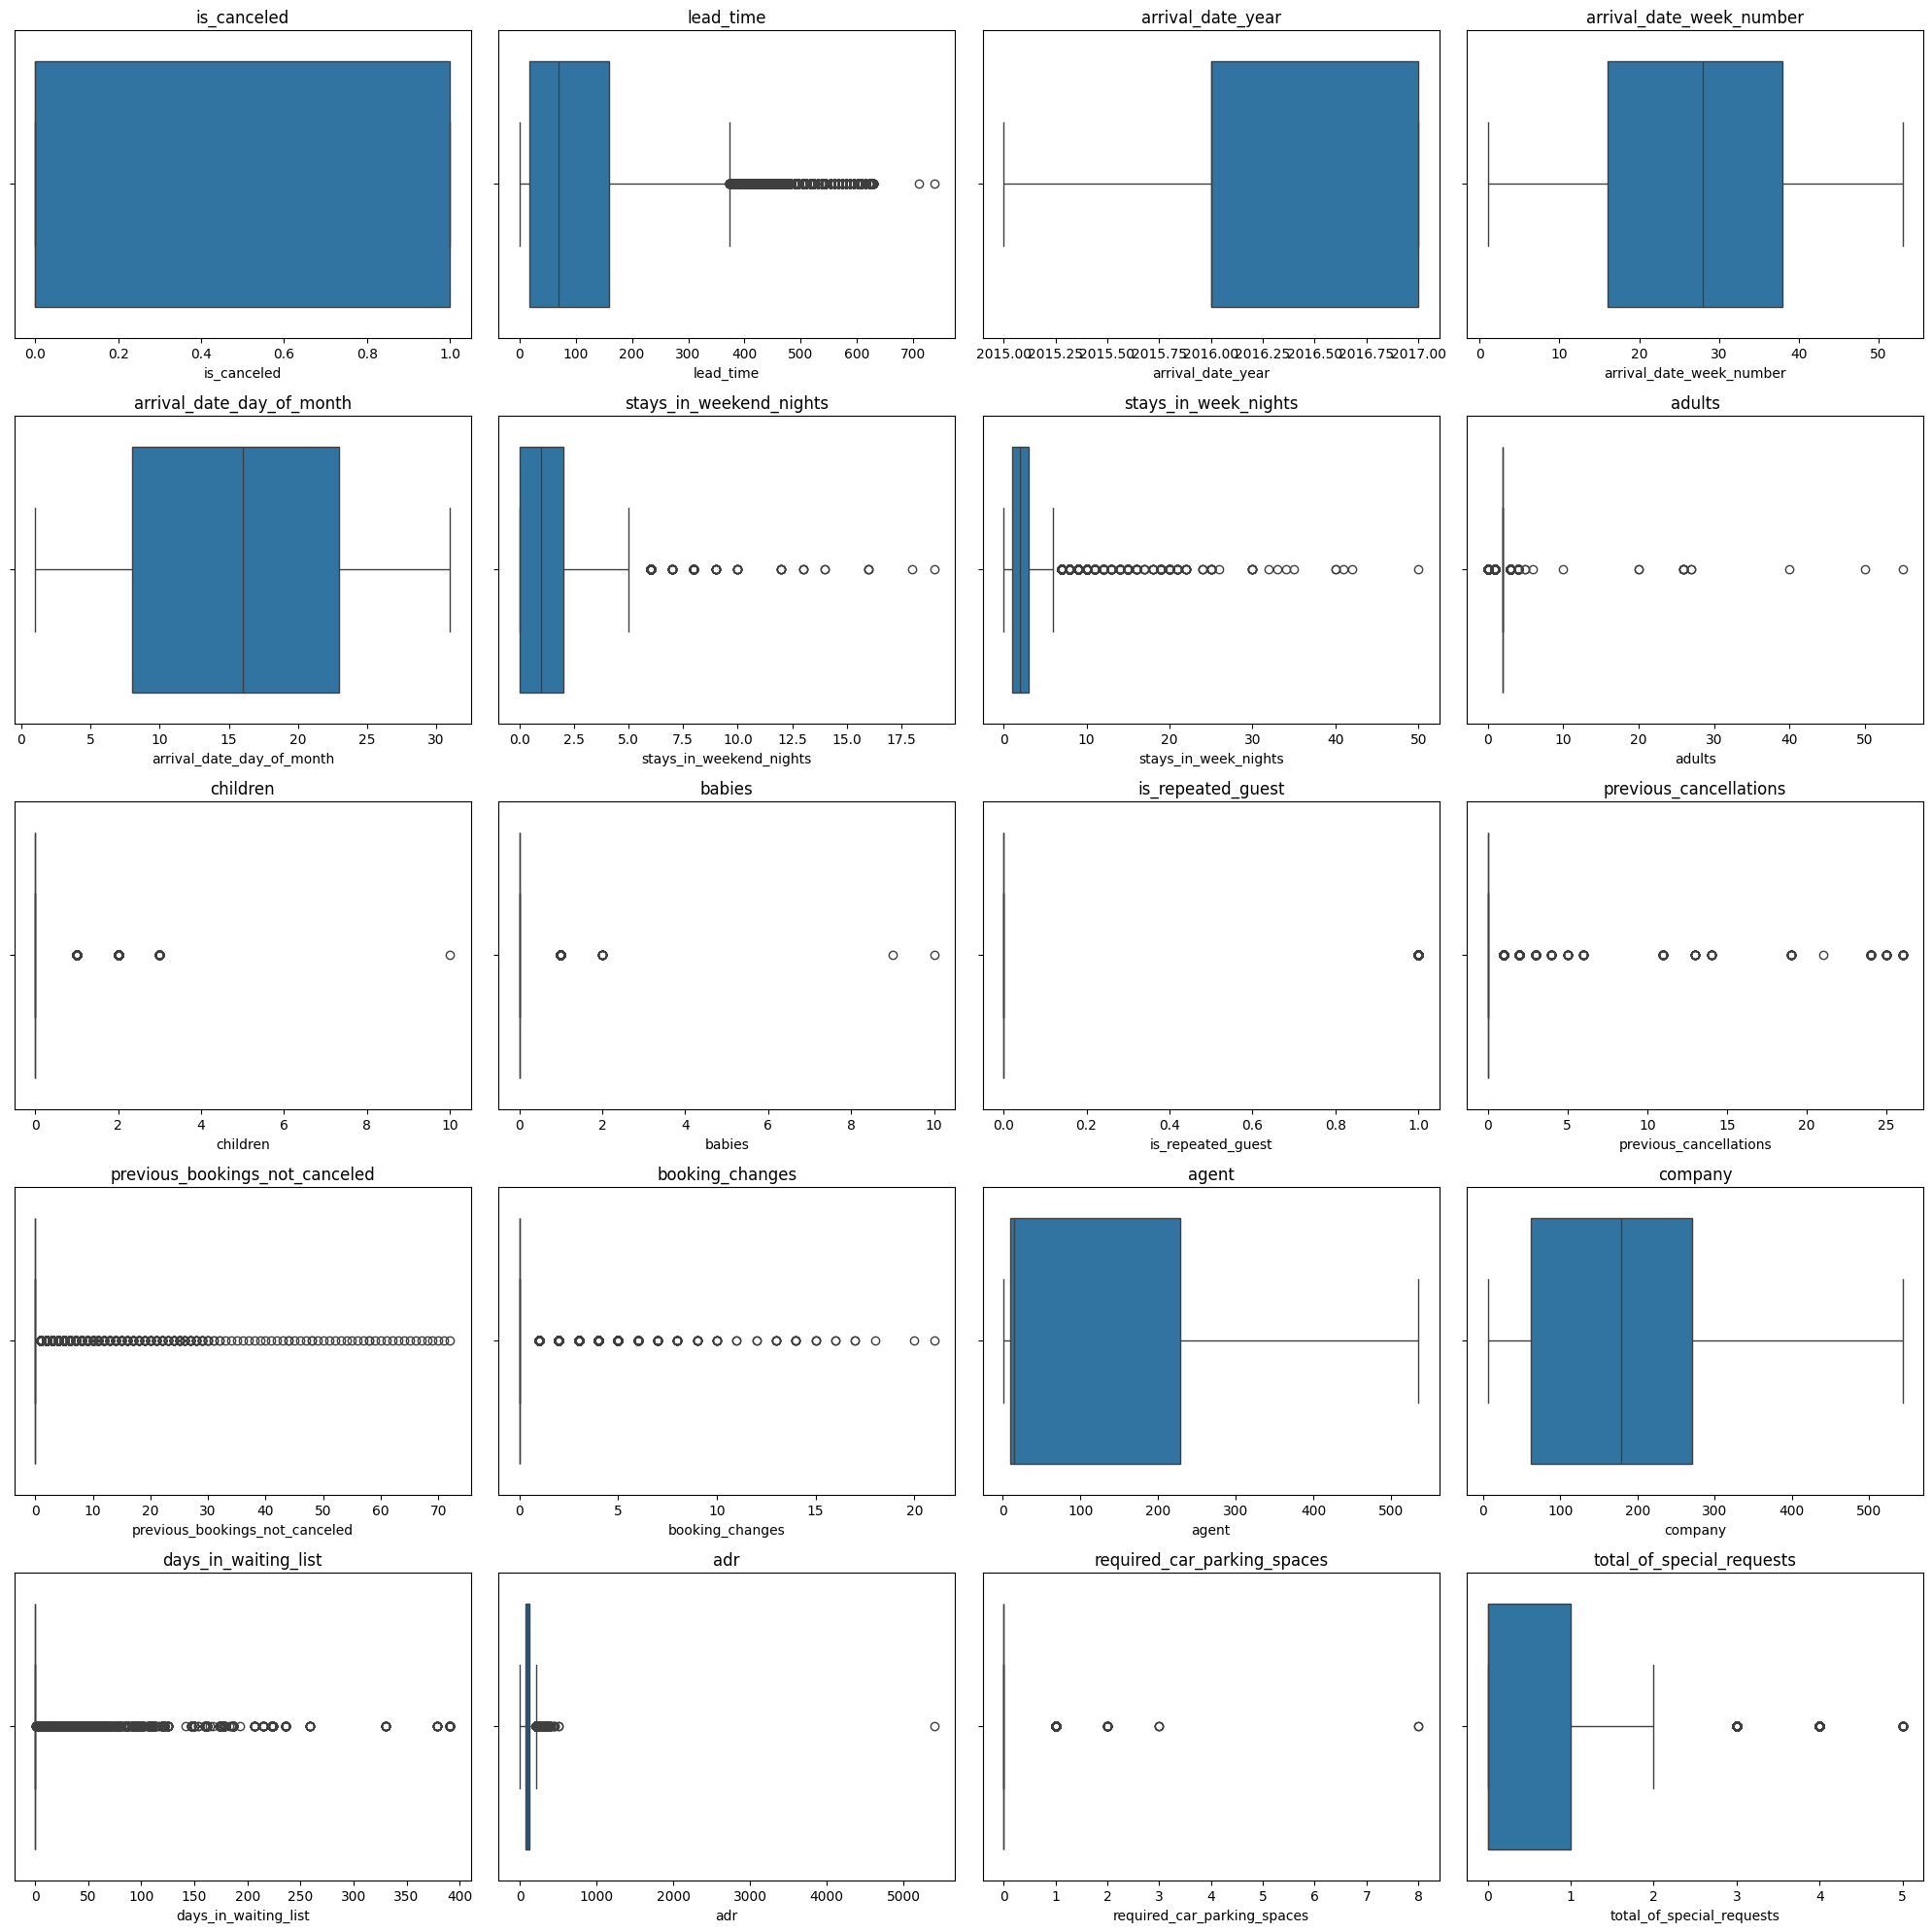

In [119]:
#check outliers 
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i , col in enumerate(numeric_col):
    sns.boxplot(data = df ,x= col, ax=axes[i] )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


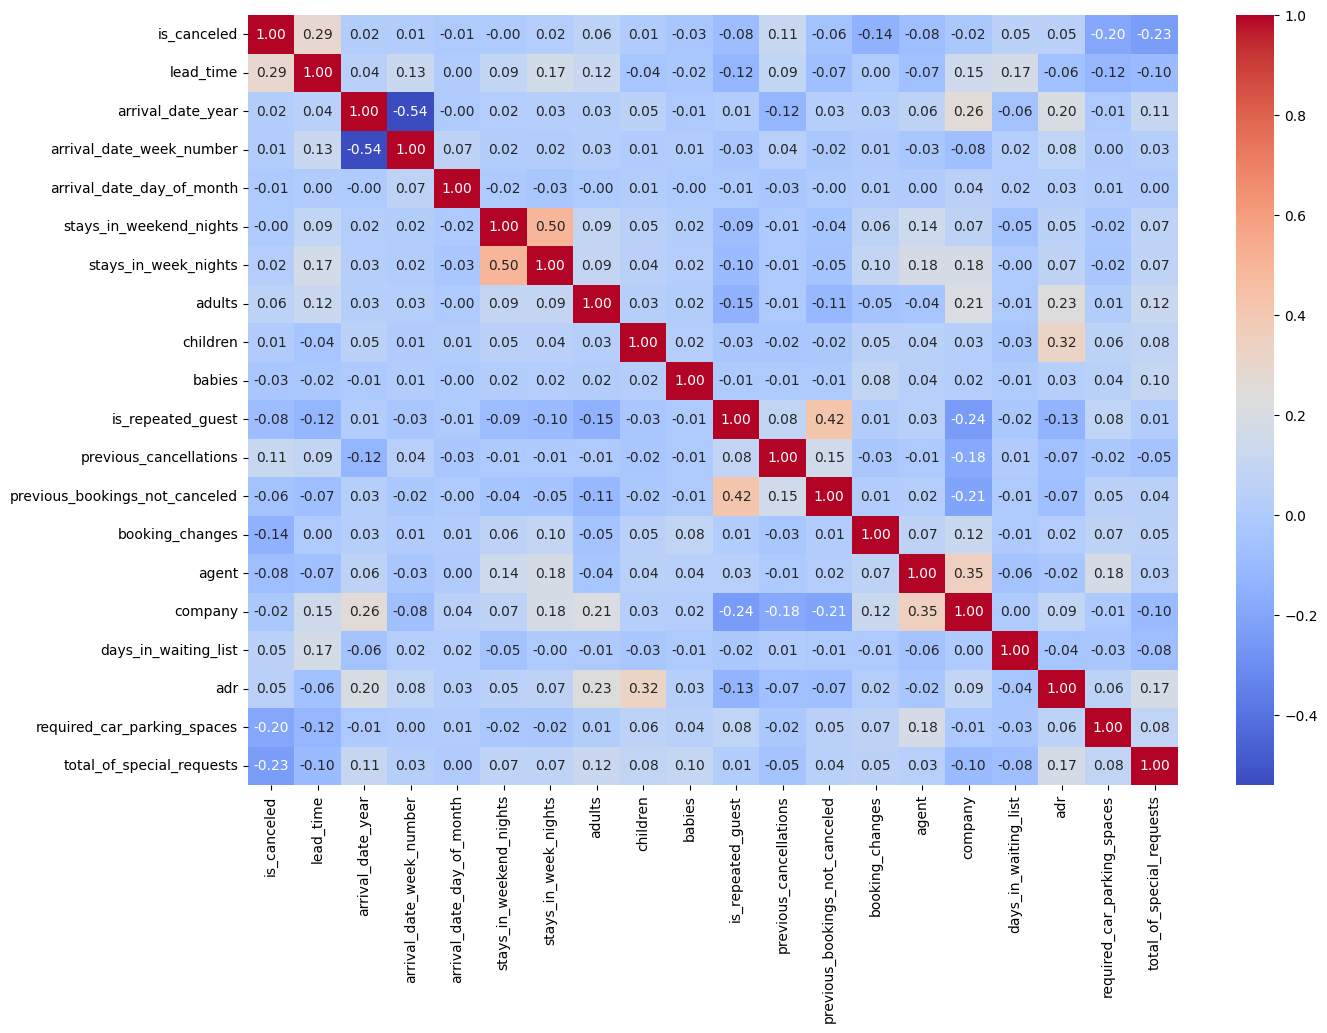

In [120]:
plt.figure(figsize=(15,10))
sns.heatmap(df[numeric_col].corr() , annot= True , cmap='coolwarm' , fmt='.2f')
plt.show()

#     2- Feature Engineering

In [121]:
df["total_stay"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

df["total_guests"] = (
    df["adults"] + df["children"].fillna(0) + df["babies"]
)

In [122]:
# Binary feature: had cancellation
df["had_previous_cancellation"] = (df["previous_cancellations"] > 0).astype(int)

In [123]:
df['room_class_changed'] = (df['reserved_room_type'] == df['assigned_room_type']).astype(int)

#     3- Cleaning

In [124]:
df.shape

(119390, 36)

Null values

In [125]:
df.isna().sum()/df.shape[0]*100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [126]:
df =df[~df['country'].isna()]
df =df[~df['children'].isna()]

drop_unnecessary col

In [127]:
df = df.drop(['reservation_status_date','reservation_status','agent','arrival_date_year','company','previous_bookings_not_canceled','distribution_channel','assigned_room_type','required_car_parking_spaces','previous_cancellations','arrival_date_week_number'],axis =1)

outliers

In [128]:
top_countries = df['country'].value_counts().head(10).index

In [129]:
df['country'] = df['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

In [130]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,118898.0,0.371352,0.483168,0.00,0.0,0.0,1.0,1.0
lead_time,118898.0,104.311435,106.903309,0.00,18.0,69.0,161.0,737.0
arrival_date_day_of_month,118898.0,15.800880,8.780324,1.00,8.0,16.0,23.0,31.0
stays_in_weekend_nights,118898.0,0.928897,0.996216,0.00,0.0,1.0,2.0,16.0
stays_in_week_nights,118898.0,2.502145,1.900168,0.00,1.0,2.0,3.0,41.0
adults,118898.0,1.858391,0.578576,0.00,2.0,2.0,2.0,55.0
children,118898.0,0.104207,0.399172,0.00,0.0,0.0,0.0,10.0
babies,118898.0,0.007948,0.097380,0.00,0.0,0.0,0.0,10.0
is_repeated_guest,118898.0,0.032011,0.176029,0.00,0.0,0.0,0.0,1.0
booking_changes,118898.0,0.221181,0.652785,0.00,0.0,0.0,0.0,21.0


In [131]:
numeric_col

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [132]:
for col in  [ 'is_repeated_guest', 'booking_changes',
       'days_in_waiting_list', 'adr']:
    print(df[col].value_counts())

is_repeated_guest
0    115092
1      3806
Name: count, dtype: int64
booking_changes
0     100902
1      12639
2       3790
3        925
4        375
5        118
6         63
7         31
8         17
9          8
10         6
14         5
13         5
15         3
17         2
16         2
12         2
11         2
20         1
21         1
18         1
Name: count, dtype: int64
days_in_waiting_list
0      115200
39        227
58        164
44        141
31        127
        ...  
81          1
92          1
74          1
167         1
36          1
Name: count, Length: 128, dtype: int64
adr
62.00     3753
75.00     2710
90.00     2471
65.00     2397
0.00      1938
          ... 
236.33       1
105.91       1
283.23       1
193.28       1
130.28       1
Name: count, Length: 8870, dtype: int64


In [133]:
df['adr'] = df['adr'].astype('float')

In [134]:
df =df[df['adults']<=4]
df=df[(df['children']!=10)]
df =df[df['babies']<=2]
df = df[df['booking_changes']<=10]


In [135]:
data =df
for col in [ 'lead_time','total_of_special_requests','adr']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) & (df[col] <= upper_bound)
    ]


In [136]:
df['market_segment'].value_counts()

market_segment
Online TA        51622
Offline TA/TO    22936
Groups           17699
Direct           11144
Corporate         5062
Complementary      672
Aviation           237
Name: count, dtype: int64

In [137]:
df['meal'] = df['meal'].replace('Undefined', 'SC')
df = df[ (df['market_segment'] != 'Undefined') ]


#     3- Save cealed data

In [138]:
df.to_csv('Cleaned_data.csv',index = False)